# Classification de texte : un détecteur de satyre

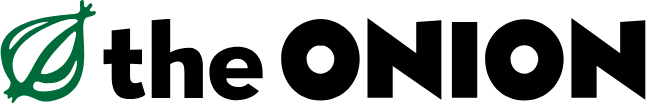

[The Onion](https://theonion.com/) est un journal satyrique américain.

&nbsp;

On y retrouve des faux articles de nouvelles humoristiques, par exemple :

- Supreme Court Overturns ‘Right V. Wrong’
- World's Scientists Admit They Just Don't Like Mice
- Publishers Break Down Door As George R.R. Martin Escapes Through Bathroom Window
- Elon Musk Files For Full Custody Of All U.S. Children
- Police Ask For Public’s Help In Falsifying Report
- AI Chatbot That Only Responds ‘Huh’ Valued At $200 Billion
- Tesla Lays Off Entire Team Behind Brakes

On va tenter d'entraîner un modèle SVM à distinguer automatiquement les articles de nouvelles de *The Onion* vs des vraies nouvelles provenant du *Huffington Post*.

In [ ]:
#@title Importations
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.preprocessing import StandardScaler

from ipywidgets import interact

import re

import requests
!pip install pyquery
from pyquery import PyQuery as pq

In [ ]:
#@title Jeu de données
df = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/headlines.csv")

# Mélange des données
df_melange = df.sample(frac=1, random_state=1337)

taille_entrainement = int(len(df) * 0.6)
taille_validation = int(len(df) * 0.2)

# Séparation entrainement-validation-test
df_entrainement = df_melange.iloc[:taille_entrainement]
df_validation = df_melange.iloc[taille_entrainement:taille_entrainement+taille_validation]
df_test = df_melange.iloc[taille_entrainement+taille_validation:]

df_entrainement

,headline,outlet
21509,insufferable 8-year-old won't stop chanting 'r...,TheOnion
4436,tania bruguera: 'in cuba we have learned our d...,HuffingtonPost
6998,dwarf actor assured guest spot on 'how i met y...,TheOnion
692,how the media devalue women,HuffingtonPost
4831,astronomers celebrate 300th anniversary of dis...,TheOnion
...,...,...
23094,scalia's utter moral failure exposed,HuffingtonPost
22560,biden pins up guitar lesson flyers on white ho...,TheOnion
18787,jack antonoff opens up about struggling with d...,HuffingtonPost
22457,students march for their lives as trump chills...,HuffingtonPost


Notre jeu de données date d'il y a quelques années déjà. On voudra s'intéresser à savoir si notre modèle fonctionne bien avec des données récentes.

La prochaine cellule contient un petit bout de code qui va **télécharger les nouvelles en première page de ces deux journaux en date d'aujourd'hui**.

In [ ]:
#@title Téléchargement des nouvelles d'aujourd'hui du Huffington Post + The Onion

# Huffington Post
r = requests.get("https://www.huffpost.com/")
titres_huffpost = [x.text for x in pq(r.text).find(".zone__content .card__headline__text")]
print(titres_huffpost)

# The Onion
r = requests.get("https://theonion.com/")
titres_the_onion = [x.text for x in pq(r.text).find("h3, h4") if x.text and x.text != "Newswire"]
print(titres_the_onion)

['Iranian Gunboats Fire On Tanker In Strait Of Hormuz As Iran Reimposes Restrictions', 'Iran Reopens Strait Of Hormuz, But Threatens To Close It Again As The US Maintains Its Blockade', 'Airline Adding Bunk Beds For Economy Travelers But Bans Crumbs, Cuddling', 'Judge Declines To Dismiss Etan Patz Murder Case, Setting Up 3rd Trial', 'Oil Plunges Below $95 As The Dow Surges 1,300 In A Worldwide Rally After Ceasefire With Iran', 'UNICEF Says Israeli Fire Kills Two Gaza Water Truck Drivers', '22 Of The Funniest Posts About Cats And Dogs This Wee', "'Narcissistic Hoovering' Is A Common Manipulation Tactic. Here’s Exactly What It Is — And Why It’s So Effective.", 'Man Accused Of Killing Charlie Kirk Pushes To Ban Cameras From Court', 'Oil Tumbles 10% And The Dow Soars More Than 1,000 Points After Iran Reopens The Strait Of Hormuz', 'A Fragile Calm In Lebanon As U.S.-Brokered Truce Holds And Families Head Home', 'U.K. Prime Minister Refuses To Resign As Epstein-Linked Ambassador Scandal Deep

## Entraîner un modèle sur du texte

Comme essentiellement tous les algos d'apprentissage machine, SVM utilise des **vecteurs de nombres** en entrée.

Comment peut-on passer de ça :

> *"Supreme Court Overturns ‘Right V. Wrong’"*

à un vecteur de nombres?

## L'approche *Sac-de-mots*

Une approche assez simple est le **sac-de-mots** (en anglais, *bag-of-words*). Il s'agit d'un vecteur à $N$ dimensions, où chaque dimension représente le nombre de fois qu'un certain mot est présent dans la phrase, peu importe l'ordre. Le nombre de dimensions $N$ correspond à la taille du vocabulaire possible.

Supposons qu'on avait comme vocabulaire possible uniquement les 8 mots suivants :

1. Le
2. Mon
3. Chat
4. Est
5. Joli
6. Grand
7. Noir
8. Et

On pourrait représenter des phrases avec des vecteurs à 8 dimensions :

```
Phrase:  "Le chat est noir"
Vecteur:
    Le    Mon   Chat   Est   Joli  Grand Noir  Et
     1      0      1     1      0      0    1   0


Phrase:  "Le chat noir est joli"
Vecteur:
    Le    Mon   Chat   Est   Joli  Grand Noir  Et
     1      0      1     1      1      0    1   0


Phrase:  "Mon grand chat noir est noir et grand"
Vecteur:
    Le    Mon   Chat   Est   Joli  Grand Noir  Et
     0      1      1     1      0      2    2   1
```


Cet exemple est très très simplifié. Dans la vraie vie, on va s'intéresser au vocabulaire complet de la langue cible, on va vite monter à plusieurs dizaines de miliers de mots de vocabulaire.

**On va donc devoir commencer par transformer chaque titre de nouvelle en vecteur de plusieurs miliers de dimensions**.

## Parlons rapidement de la RAM...

*RAM = Random Access Memory*

C'est la composante de l'ordinateur qui est faite pour contenir les données des variables pendant l'exécution d'un programme.

En date de 2026, *Google Colab* vous alloue 12GB de RAM pour exécuter votre code. Vous pouvez d'ailleurs surveiller la quantité de RAM utilisée par vos variables en cliquant ici :

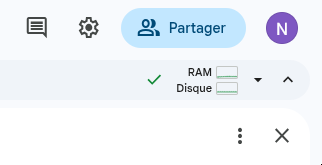

Ça vous donne une vue d'ensemble de votre utilisation des ressources :

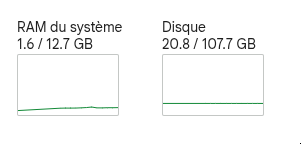

**Si la quantité de données utilisées par votre code dépasse les ~12GB, votre session va planter, avec l'erreur :**

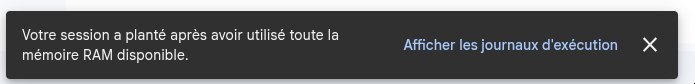

Votre session redémarre alors... Vous devez ré-exécuter les cellules précédentes.

&nbsp;

Si je vous parle de ça,

## Préparation du jeu de données

On va construire un *sac de mots* en y allant étape par étape :

1. Trouver le vocabulaire possible
2. Faire une fonction qui transforme une seule phrase en vecteur sac de mot
3. Transformer tout le jeu de données en tableau 2D, où chaque ligne est un sac de mots pour une phrase différente

In [ ]:
#@title Exercice 1 : Construire le vocabulaire

# Fonction fournie : la fonction enlève la ponctuation à gauche/à droite d'un mot
def normaliser_mot(mot):
  mot = re.sub(r'[^a-z]*(.+)\b[^a-z]*$', r'\1', mot.lower())
  return mot

################

### Faites une boucle sur l'ensemble d'__entraînement__ (df_entrainement)
### Pour chaque ligne de texte (headline), faites un texte.split() pour obtenir un tableau de vocabulaire,
### puis enlevez la ponctuation au début et à la fin avec la méthode normaliser_mot() fournie.
### Ajoutez chaque mot à un gros tableau, en vous assurant que chaque mot apparaît une seule fois maximum
vocabulaire = []

for i, nouvelle in df_entrainement.iterrows():
  for mot in nouvelle.headline.split():
    mot = normaliser_mot(mot)
    if mot not in vocabulaire:
      vocabulaire.append(mot)

print(vocabulaire[:5]) # 5 premiers mots

['insufferable', 'year-old', "won't", 'stop', 'chanting']


In [ ]:
#@title Exercice 2 : transformer une phrase en vecteur
### Complétez la fonction sac_de_mots(), qui prend en paramètre "phrase"
### (un texte) et "vocabulaire" (un tableau de mots uniques) et qui retourne un
### sac de mots, ie, un tableau avec le nombre d'occurences de chaque mot possible
### du vocabulaire
def sac_de_mots(phrase, vocabulaire):
  return ... # TODO

#############

def sac_de_mots(phrase, vocabulaire):
  sac_de_mots = np.zeros(len(vocabulaire))

  for mot in phrase.lower().split():
    mot = normaliser_mot(mot)
    if mot in vocabulaire:
      index = vocabulaire.index(mot)
      sac_de_mots[index] += 1

  return sac_de_mots

##### tests

# Pour valider la fonction sac_de_mots(), utilisez ce petit vocabulaire plutôt
# que celui trouvé dans l'exercice 1.1, question que ça aille un peu plus vite
vocabulaire_pour_tester = ['le', 'mon', 'chat', 'est', 'joli', 'grand', 'noir', 'et']

print(sac_de_mots('le chat est joli', vocabulaire_pour_tester))
print(sac_de_mots("Le chat, noir, est joli", vocabulaire_pour_tester))
print(sac_de_mots("Mon grand chat noir est noir et grand", vocabulaire_pour_tester))

# Qu'est-ce qui se passe si on a des mots qui n'ont jamais été vus avant?
print(sac_de_mots("Mon grand chat noir, très joli, est noir et très grand", vocabulaire_pour_tester))

[1. 0. 1. 1. 1. 0. 0. 0.]
[1. 0. 1. 1. 1. 0. 1. 0.]
[0. 1. 1. 1. 0. 2. 2. 1.]
[0. 1. 1. 1. 1. 2. 2. 1.]


In [ ]:
#@title Exercice 3 : Construire les jeux de données d'entraînement/validation/test

def calculer_X(dataframe):
  # Utilisez une boucle qui parcours les dataframe.headline
  # et retournez un tableau numpy avec une ligne par headline, où
  # chaque ligne est un sac-de-mots
  pass

#######

def calculer_X(dataframe):
  X = []

  for headline in dataframe.headline:
    X.append(sac_de_mots(headline, vocabulaire))

  return np.array(X)

##### tests

X_entrainement = calculer_X(df_entrainement)
X_validation = calculer_X(df_validation)
X_test = calculer_X(df_test)

y_entrainement = df_entrainement.outlet
y_validation = df_validation.outlet
y_test = df_test.outlet

print(X_entrainement.shape)
print(X_validation.shape)
print(X_test.shape)

X_entrainement

(17171, 22843)
(5723, 22843)
(5725, 22843)


array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

### ⚠️ **Dépannage** ⚠️

À ce stade-ci, selon ce que vous avez fait, vous allez potentiellement avoir **fait exploser la RAM allouée pour votre notebook**.

À mesure que vous testez des choses, vous pourriez avoir créé des variables temporaires qui restent là dans votre notebook...

&nbsp;

Quand c'est des nombres ou des petits tableaux, ce n'est pas la fin du monde, mais les derniers exercices mènent à des très gros tableaux : transformer chaque

$$28~619 \text{ nouvelles } * 23~425 \text{ mots } = 670~400~075$$

Un peu moins de 700 millions de cases au total.

&nbsp;

12GB de RAM, c'est suffisant pour stocker tout ça, mais ce n'est pas suffisant pour stocker *plusieurs fois ça*.

**⚠️ Si le notebook crash, redémarrez-le et ré-exécutez les cellules. ⚠️**

## Entraînement et évaluation

Entraînez plusieurs SVM pour trouver la valeur de l'hyperparamètre $C$.

Testez les valeurs suivantes pour $C$ : 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100

In [ ]:
#@title Exercice 4

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
  model = LinearSVC(C=C)
  model.fit(X_entrainement, y_entrainement)

  y_predictions = model.predict(X_validation)
  print("C=", C, " --> exactitude de ", accuracy_score(y_validation, y_predictions))

C= 0.001  --> exactitude de  0.79154289708195
C= 0.01  --> exactitude de  0.8273632710117071
C= 0.1  --> exactitude de  0.8352262799231173
C= 1  --> exactitude de  0.820024462694391


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C= 10  --> exactitude de  0.8067447143106762


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C= 100  --> exactitude de  0.8030753101520182


Pour avoir une idée de la qualité du modèle, on peut regarder ce qu'un classifieur stupide ferait (toujours dire la réponse la plus probable).

On va comparer notre meilleur modèle avec un `DummyClassifier`

In [ ]:
#@title Comparaison avec une basline

model_dummy = DummyClassifier()
model_dummy.fit(X_entrainement, y_entrainement)

y_predictions = model_dummy.predict(X_validation)
print("Exactitude de validation:", accuracy_score(y_validation, y_predictions))

# Tableau numpy 2D:
matrice = confusion_matrix(y_validation, y_predictions, normalize='pred')

# On la transforme en DataFrame pour l'inspecter:
df_confusion = pd.DataFrame(
    matrice,
    columns=model_dummy.classes_,
    index=model_dummy.classes_
)
# Visualisation sous forme de carte thermique
display(px.imshow(df_confusion,
                  text_auto=True, title="Matrice de confusion (en pourcentages)",
                  labels={"x": "Prediction", "y": "Vraie classe"}))

Exactitude de validation: 0.5226279923117246


In [ ]:
#@title Matrice de confusion du meilleur modèle et tests manuels

C = 99999 ### TODO : Remplacer par le meilleur C que vous avez trouvé

##########

C = 0.1

########## tests

meilleur_modele = LinearSVC(C=C)
meilleur_modele.fit(X_entrainement, y_entrainement)

y_predictions = meilleur_modele.predict(X_validation)
print("Exactitude de validation:", accuracy_score(y_validation, y_predictions))

# Tableau numpy 2D:
matrice = confusion_matrix(y_validation, y_predictions, normalize='pred')

# On la transforme en DataFrame pour l'inspecter:
df_confusion = pd.DataFrame(
    matrice,
    columns=meilleur_modele.classes_,
    index=meilleur_modele.classes_
)
# Visualisation sous forme de carte thermique
display(px.imshow(df_confusion,
                  text_auto=True, title="Matrice de confusion (en pourcentages)",
                  labels={"x": "Prediction", "y": "Vraie classe"}))

Exactitude de validation: 0.8352262799231173


In [ ]:
#@title Validation manuelle du modèle : widget pour essayer des titres et voir la prédiction
def afficher_detection(phrase):
  sac = sac_de_mots(phrase, vocabulaire)
  prediction = meilleur_modele.predict([sac])[0]
  print(prediction)
  inspect = pd.DataFrame({"vocabulaire": vocabulaire, "nb": sac})
  display(inspect[inspect.nb > 0])

output = interact(
  afficher_detection,
  phrase="World's Scientists Admit They Just Don't Like Mice"
)

interactive(children=(Text(value="World's Scientists Admit They Just Don't Like Mice", description='phrase'), …

Vous pouvez utiliser des nouvelles provenant des deux sites pour tester votre modèle :

- https://www.huffpost.com/
- https://theonion.com/

La prochaine cellule contient un petit extrait de code qui évalue la classification des nouvelles d'aujourd'hui depuis ces deux sites pour voir si nos résultats tiennent la route.

In [ ]:
#@title Regarder ce que ça donne avec les nouvelles d'aujourd'hui
y_nouvelles_du_jour = ['HuffingtonPost'] * len(titres_huffpost) + ['TheOnion'] * len(titres_the_onion)
y_predictions = meilleur_modele.predict([
  sac_de_mots(x, vocabulaire)
  for x in titres_huffpost + titres_the_onion
])

print(accuracy_score(y_nouvelles_du_jour, y_predictions))

# Tableau numpy 2D:
matrice = confusion_matrix(y_nouvelles_du_jour, y_predictions, normalize='true')

# On la transforme en DataFrame pour l'inspecter:
df_confusion = pd.DataFrame(
    matrice,
    columns=meilleur_modele.classes_,
    index=meilleur_modele.classes_
)
# Visualisation sous forme de carte thermique
display(px.imshow(df_confusion,
                  text_auto=True, title="Matrice de confusion (en pourcentages)",
                  labels={"x": "Prediction", "y": "Vraie classe"}))


0.8134328358208955


# Limitations de la représentation *Sac-de-mots* et pistes de solutions

Insistons sur quelque chose d'important ici : la représentation *sac-de-mots* n'est **pas la seule possible**.

Ce n'est d'ailleurs pas la représentation utilisée par les LLMs (ChatGPT, Claude, ...).

&nbsp;

Parlons de quelques défauts de cette représentation :

&nbsp;

**1. Très coûteux en espace**

On a un jeu de données relativement petit, on a seulement pris un extrait des nouvelles de deux journaux, et on passe déjà proche de faire exploser la RAM fournie par Colab)

&nbsp;

**2. Chaque déclinaison d'un même mot (masculin/féminin, singulier/pluriel, conjugaisons, ...) est représentée par une dimension différente**

*"Les chats sont beaux"* est un vecteur complètement différent de *"La chatte est belle"*, car ces deux phrases n'ont aucun mot en commun.

&nbsp;

&nbsp;

**3. L'ordre des mots n'est pas considéré, donc les séquences de mots ne sont pas reconnues**

Dans un *sac-de-mots*, *"mon chat est beau"* a exactement la même représentation que *"beau mon est chat"*.

Ça va avoir un impact important quand on regarde le sens de certaines **séquences de mots**. Les phrases :

- *"très bien, pas mauvais"*
- *"très mauvais, pas bien"*

sont toutes les deux représentées par le même sac-de-mots.

## Solutions possibles pour ces quelques problèmes

On peut adapter l'approche *sac-de-mots* pour répondre à certains de ces problèmes :

**1. Utiliser une structure *éparse* pour nos données**

Est-ce qu'on a vraiment besoin de 8GB de données pour tous ces sacs-de-mots?


Si on inspecte les données d'entraînement, on va se rendre compte que **seulement 170 334 des ~400M de cases contiennent des valeurs**. On a essentiellement une grosse matrice pleine de zéros :

```
     [[1., 1., 1., ..., 0., 0., 0.],
      [0., 0., 0., ..., 0., 0., 0.],
      [0., 0., 0., ..., 0., 0., 0.],
      ...,
      [0., 0., 0., ..., 0., 1., 0.],
      [0., 0., 0., ..., 0., 0., 0.],
      [0., 0., 0., ..., 0., 0., 1.]])
```

`sklearn` est capable d'utiliser des meilleures *structures de données* que ça quand on sait que nos données sont majoritairement composées de zéros.

&nbsp;

**2. Forcer une invariance au masculin/féminin, singulier/pluriel**

On aimerait avoir un algorithme **invariant** aux variations masculin/féminin, singulier/pluriel et autres. On veut s'assurer que la réponse donnée ne change pas si on met un mot au pluriel dans un titre de nouvelle testé.

Une façon d'éviter d'avoir *Chat*, *Chatte*, *Chattes* et *Chats* comptés comme étant 4 mots totalement différents est de faire une transformation des mots au moment de calculer le vocabulaire possible.

En traîtement de langage, on parle de **racinisation** (en anglais: *stemming*) : on applique un algorithme sur chaque mot qui essaie de couper les suffixes pour ramener chaque mot à une racine commune, par exemple :

- Si le mot a un "s" à la fin, enlever le s
- Si le mot termine par "aux", enlever le x final
- Si le mot termine par "atte", garder seulement "at"
- Si le mot termine par "ent", garder seulement "e"
- Si le mot termine par "er", garder seulement "e"
- ...
- ...

Des algorithmes pour différentes langues ont été définis à la main par des linguistes, on pourrait utiliser une fonction pré-existante qui applique un grand nombre de règles pour transformer nos mots :

- manger -> mange
- mangent -> mange
- cadeaux -> cadeau
- chattes -> chat
- chats -> chat
- cadeaux -> cadeau
- ...

&nbsp;

**3. Sac-de-$n$-grammes**

Pour garder un peu de contexte, on pourrait utiliser des **$n$-grammes**. Un $n$-gramme est une sous-séquence de taille n. Dans le contexte, ça veut dire :

- Uni-gramme : un mot individuel
- Bi-gramme : une séquence de deux mots consécutifs
- Tri-gramme : trois mots consécutifs
- $n$-gramme : $n$ mots consécutifs

Plutôt que de considérer dans notre vocabulaire uniquement les mots individuels, on pourrait aussi ajouter **les paires, triplets, ... de mots consécutifs**. On adapterait le vocabulaire avec :


- Le
- Mon
- Chat
- Est
- Joli
- Grand
- Noir
- Et
- Le chat
- chat est
- est grand
- grand et
- et beau
- Mon chat
- est joli
- et grand
- et noir
- ...

**Ça augmenterait significativement le nombre de dimensions**, donc l'*amélioration 1* citée plus haut va être absolument nécessaire si on ajoute ça.

In [ ]:
#@title Démo : racinisation de mots en anglais
import nltk
from nltk.stem.snowball import EnglishStemmer

stemmer = EnglishStemmer()

def raciniser_anglais(mot):
  mot = re.sub(r'[^a-z]*(.+)\b[^a-z]*$', r'\1', mot.lower())
  mot = stemmer.stem(mot)
  return mot

print(raciniser_anglais("trying"))
print(raciniser_anglais("tries"))
print(raciniser_anglais("try"))
print(raciniser_anglais("tried"))

print(raciniser_anglais("eat"))
print(raciniser_anglais("eating"))
print(raciniser_anglais("eatings"))
print(raciniser_anglais("eats"))


out = interact(raciniser_anglais, mot="eatings")

tri
tri
tri
tri
eat
eat
eat
eat


interactive(children=(Text(value='eatings', description='mot'), Output()), _dom_classes=('widget-interact',))

In [ ]:
#@title Démo : construction du jeu de données X_entrainement_v2, avec les améliorations proposées
from sklearn.feature_extraction.text import CountVectorizer

analyzer = CountVectorizer().build_analyzer()

def raciniser_document(doc):
  for mot in analyzer(doc):
    # (2) Racinisation des mots
    mot = raciniser_anglais(mot)
    yield mot

# (3) On garde un peu de contexte avec des bi-grammes
def extract(doc, min_ngrams=1, max_ngrams=2):
  for n in range(min_ngrams, max_ngrams+1):
    for ngram in nltk.ngrams(raciniser_document(doc), n):
      yield ngram

count_vectorizer = CountVectorizer(
    analyzer=extract,
)

count_vectorizer.fit(df_entrainement.headline)

X_entrainement_v2 = count_vectorizer.transform(df_entrainement.headline)
X_validation_v2 = count_vectorizer.transform(df_validation.headline)
X_test_v2 = count_vectorizer.transform(df_test.headline)

# (1) Matrice éparse
display(X_entrainement_v2)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 324189 stored elements and shape (17171, 118253)>

In [ ]:
#@title Recherche d'hyperparamètre C pour un SVM sur la nouvelle version du jeu de données

for C in [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]:
  model = LinearSVC(C=C, max_iter=4000)
  model.fit(X_entrainement_v2, y_entrainement)

  y_predictions = model.predict(X_validation_v2)
  print("C=", C, " --> exactitude de ", accuracy_score(y_validation, y_predictions))

C= 1e-05  --> exactitude de  0.680237637602656
C= 0.0001  --> exactitude de  0.7244452210379172
C= 0.001  --> exactitude de  0.7892713611742094
C= 0.01  --> exactitude de  0.8270138039489778
C= 0.1  --> exactitude de  0.836973615236764
C= 1  --> exactitude de  0.8338284116721999
C= 10  --> exactitude de  0.8338284116721999


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



C= 100  --> exactitude de  0.8340031452035646
C= 1000  --> exactitude de  0.8338284116721999


In [ ]:
#@title Évaluation sur l'ensemble de test et utilisation du modèle

C = 99999 ### TODO : Remplacer par le meilleur C que vous avez trouvé

#########

C = 0.1

####### tests
model_final = LinearSVC(C=C, max_iter=4000)
model_final.fit(X_entrainement_v2, y_entrainement)

y_predictions = model_final.predict(X_test_v2)
print("Exactitude de test:", accuracy_score(y_test, y_predictions))

# Tableau numpy 2D:
matrice = confusion_matrix(y_test, y_predictions, normalize='pred')

# On la transforme en DataFrame pour l'inspecter:
df_confusion = pd.DataFrame(
    matrice,
    columns=model_final.classes_,
    index=model_final.classes_
)
# Visualisation sous forme de carte thermique
display(px.imshow(df_confusion,
                  text_auto=True, title="Matrice de confusion (en pourcentages)",
                  labels={"x": "Prediction", "y": "Vraie classe"}))


Exactitude de test: 0.8443668122270742


In [ ]:
#@title Visualisation des prédictions pour l'ensemble de test
def afficher_detection(phrase):
  mots = count_vectorizer.transform([phrase])
  prediction = model_final.predict(mots)[0]
  print(prediction)
  inspect = pd.DataFrame({
      "vocabulaire": count_vectorizer.get_feature_names_out(),
      "nb": np.array(mots.todense()).reshape(-1)
  })
  display(inspect[inspect.nb > 0])

output = interact(
  afficher_detection,
  phrase="World's Scientists Admit They Just Don't Like Mice"
)

interactive(children=(Text(value="World's Scientists Admit They Just Don't Like Mice", description='phrase'), …

In [ ]:
#@title Regarder ce que ça donne avec les nouvelles d'aujourd'hui
y_nouvelles_du_jour = ['HuffingtonPost'] * len(titres_huffpost) + ['TheOnion'] * len(titres_the_onion)
X_nouvelles_du_jour = titres_huffpost + titres_the_onion
y_predictions = model_final.predict(count_vectorizer.transform(X_nouvelles_du_jour))

print(accuracy_score(y_nouvelles_du_jour, y_predictions))

# Tableau numpy 2D:
matrice = confusion_matrix(y_nouvelles_du_jour, y_predictions, normalize='true')

# On la transforme en DataFrame pour l'inspecter:
df_confusion = pd.DataFrame(
    matrice,
    columns=model_final.classes_,
    index=model_final.classes_
)
# Visualisation sous forme de carte thermique
display(px.imshow(df_confusion,
                  text_auto=True, title="Matrice de confusion (en pourcentages)",
                  labels={"x": "Prediction", "y": "Vraie classe"}))


0.8656716417910447


# Réflexions sur le modèle : tenter de comprendre ce qui se passe sous le capot

On a un modèle qui donne des résultats intéressants (~83-84%, ce n'est pas parfait mais c'est certainement mieux que le hasard qui nous donnerait 50%). **Pourquoi est-ce que ça marche?** Les raisons sont assez difficiles à comprendre à première vue...

C'est un peu le danger avec des modèles d'apprentissage machine : quand ça marche, on n'a pas d'explication claire autre que "c'est le modèle qui marchait le mieux avec nos données".

Même chose quand ça ne marche pas : la cause des mauvaises réponses n'est pas simple à expliquer.

&nbsp;

**Interpréter les coefficients appris par le SVM**

L'interprétation *géométrique* des valeurs apprises par un SVM :

- En 2D, ça trouve une **droite** qui sépare les différentes catégories de points
- En 3D, ça trouve un **plan** qui sépare des points
- En plus de dimensions que ça, ça calcule une distance entre un point et un **hyperplan**

On peut cependant voir le SVM du point de vue du **seuil sur une somme pondérée**. Le SVM apprend les coefficients d'une somme pondérée :

$$m_1 x_1 + m_2 x_2 + m_3 x_3 + \ldots + m_N x_N + b = 0$$

Le choix de la classe d'un nouveau point est décidé en regardant si on est en-dessous ou au-dessus de zéro, donc :

\begin{align*}
m_1 x_1 + m_2 x_2 + m_3 x_3 + \ldots + m_N x_N + b & > 0 \\
m_1 x_1 + m_2 x_2 + m_3 x_3 + \ldots + m_N x_N & > -b
\end{align*}

&nbsp;

Quand notre modèle calcule que "Le chat est beau", le sens de ce calcul sur notre sac-de-mots est :

\begin{align*}
0.012 & x_\text{le} + -0.114 x_\text{mon} + -0.311 x_\text{chat} + 0.018 x_\text{est} \\
+ 0.512 &x_\text{joli} + -0.419 x_\text{grand} +
0.023 x_\text{noir} + 0.002 x_\text{et} > -0.37
\end{align*}


In [ ]:
#@title Visualiser les coefficients appris pour chaque mot
print("Seuil à atteindre avec la somme pondérée:", -model_final.intercept_[0])

df_inspection_svm = pd.DataFrame({
  "coefficient": model_final.coef_[0],
  "mot": count_vectorizer.get_feature_names_out(),
})

# On prend les coefficients les plus importants seulement
display(df_inspection_svm[df_inspection_svm.coefficient.abs() > 0.2].sort_values("coefficient", ascending=False))

def afficher_detection(phrase):
  mots = count_vectorizer.transform([phrase])
  prediction = model_final.predict(mots)[0]
  somme_ponderee = (model_final.coef_[0].reshape(-1) * np.array(mots.todense()).reshape(-1)).sum()
  print("Somme pondérée:", somme_ponderee, ">", -model_final.intercept_[0],
        "=>", somme_ponderee > -model_final.intercept_[0])
  print(prediction)

output = interact(
  afficher_detection,
  phrase="local area onion"
)

Seuil à atteindre avec la somme pondérée: 0.08526926018382527


,coefficient,mot
39949,0.770262,"(fuck,)"
7096,0.727954,"(area,)"
59641,0.668722,"(local,)"
52564,0.645266,"(introduc,)"
74317,0.601459,"(onion,)"
...,...,...
66678,-0.536863,"(my,)"
4995,-0.544241,"(and,)"
113537,-0.568668,"(whi,)"
4739,-0.571953,"(an,)"


interactive(children=(Text(value='local area onion', description='phrase'), Output()), _dom_classes=('widget-i…

On peut rapidement remarquer deux choses en regardant le score de ces mots :

1. Un langage grossier est un bon indicateur qu'on a un article de *The Onion*
2. Le mot *the* est fortement associé au *Huffington Post*...

Si on inspecte un peu, on va se rendre compte que stylistiquement, *The Onion* utilise effectivement beaucoup moins souvent le mot "The" dans ses titres :

In [ ]:
#@title Nombre d'articles dans chaque journal avec le mot "the" présent dans le titre
df[df.headline.apply(lambda x: "the" in x.lower().split())].outlet.value_counts()

,count
outlet,
HuffingtonPost,4025
TheOnion,664


Avec les coefficients, on peut également chercher des effets bizarres : certains mots uniques vont avoir un score qui sont très proches du seuil à eux seuls.

In [ ]:
#@title Mots uniques dont le coefficient est très proche du seuil
display(df_inspection_svm[
    np.logical_and(
        (df_inspection_svm.coefficient + model_final.intercept_[0]).abs() < 0.06,
        df_inspection_svm.mot.apply(lambda x: len(x) == 1))
].sort_values("coefficient", ascending=False))

def afficher_detection(phrase):
  mots = count_vectorizer.transform([phrase])
  prediction = model_final.predict(mots)[0]
  somme_ponderee = (model_final.coef_[0].reshape(-1) * np.array(mots.todense()).reshape(-1)).sum()
  print("Somme pondérée:", somme_ponderee, ">", -model_final.intercept_[0],
        "=>", somme_ponderee > -model_final.intercept_[0])
  print(prediction)

output = interact(
  afficher_detection,
  phrase="clap"
)

,coefficient,mot
93216,0.145235,"(sniper,)"
33201,0.145229,"(everyth,)"
57037,0.145103,"(laid,)"
118186,0.144647,"(zogbi,)"
20231,0.144554,"(classmat,)"
...,...,...
20108,0.025367,"(clap,)"
15034,0.025365,"(brotherhood,)"
44064,0.025292,"(hadn,)"
12944,0.025292,"(birthright,)"


interactive(children=(Text(value='clap', description='phrase'), Output()), _dom_classes=('widget-interact',))

**QUESTION 5**

Trouvez les deux mots qui, lorsqu'utilisés seul dans le titre, sont les plus proches de la limite de classification entre TheOnion et HuffingtonPost.


In [ ]:
#@title Question 5
df_q5 = df_inspection_svm.assign(distance_intercept=(df_inspection_svm.coefficient + model_final.intercept_[0]).abs())[
    df_inspection_svm.mot.apply(lambda x: len(x) == 1)
]

print(df_q5[df_q5.coefficient > 0].sort_values("distance_intercept").iloc[0].mot)
print(df_q5[df_q5.coefficient < 0].sort_values("distance_intercept").iloc[0].mot)

('mug',)
('inhuman',)


**RÉPONSE**

Tout va dépendre du modèle appris, ça pourrait changer d'une exécution à l'autre

## Qu'est-ce qu'on peut dire au sujet de notre modèle?

On peut d'abord se demander : qu'est-ce que notre modèle est capable de faire?

Est-ce...

- Détecter de la satyre/des blagues en général
- Distinguer le style d'écriture de *The Onion* du *Huffington Post*

&nbsp;

Nos données ne sont pas assez diversifiées pour qu'on puisse raisonnablement s'attendre à détecter **tout** type de satyre. De plus, notre modèle a fort probablement appris à reconnaître des choses spécifiques à ces deux journaux.

Le fait que le mot "The" soit aussi fortement associé à un des deux journaux plutôt que l'autre est un bon indice du fait que c'est le **style d'écriture** plutôt que les blagues en général qui fait l'objet de notre détection à ~84% d'exactitude.

&nbsp;

> *Parenthèse sur cette tâche* : les auteurs du jeu de données qu'on utilise dans ce module prétendent pouvoir utiliser ces données pour arriver à une exactitude de 90% sur la tâche générale de *"détection de sarcasme"*, ce qui semble trompeur. Leurs propres résultats (vers la fin de l'article) confirment que les mots les plus importants dans leur modèle sont des mots que les articles de *The Onion* en particulier utilisent souvent : man, local, nation, area ...
> L'article, qui date de 2018, n'a pas été publié dans un journal avec revue par les pairs : https://arxiv.org/abs/1908.07414

&nbsp;

## Interprétabilité limitée des coefficients

Pourquoi le coefficient du mot "mon" devrait-il être à -0.114? *Parce que ça donnait le meilleur résultat sur nos données.*

Pourquoi le coefficient du mot "grand" devrait-il être à -0.419? *Parce que ça donnait le meilleur résultat sur nos données.*

&nbsp;

Notre modèle a appris quelque chose qui maximise le nombre de bonnes réponses, mais ces nombres ne sont pas simples à interpréter et ne nous aide pas forcément à *comprendre* tout ce qui caractérise le style d'écriture de The Onion.

Comme dans beaucoup de cas en IA, on a ici un modèle de type **boîte noire**. On ne comprend pas bien les raisons derrière les décisions prises, mis à part le fait que c'est ce qui marchait le mieux en général.

## Problèmes possibles sur les mots rares

Qu'est-ce que notre modèle a appris à faire avec des **mots ou bi-grammes rares**?

Certains mots comme *"8-year-old"* arrivent une et une seule fois dans tous nos exemples connus.

Si 100% des exemples qu'on a avec "8-year-old" sont attachés à *The Onion*, est-ce que c'est une information importante à considérer?

In [ ]:
#@title Code qui liste les mots qui arrivent une seule fois

mots = set()
mots_multiples = set()

for i, nouvelle in df_entrainement.iterrows():
  for mot in nouvelle.headline.split():
    mot = raciniser_anglais(mot)
    if mot in mots:
      mots_multiples.add(mot)
    mots.add(mot)

mots_uniques = mots - mots_multiples

df_inspection_svm = pd.DataFrame({
  "coefficient": model_final.coef_[0],
  "mot": count_vectorizer.get_feature_names_out(),
})
df_inspection_svm[df_inspection_svm.mot.apply(lambda x: len(x) == 1 and x[0] in mots_uniques)].sort_values('coefficient')

,coefficient,mot
32751,-0.175759,"(esteem,)"
116923,-0.161671,"(wrench,)"
99228,-0.156425,"(tehran,)"
17986,-0.150476,"(catcal,)"
2206,-0.147358,"(ado,)"
...,...,...
93102,0.169164,"(smitten,)"
112604,0.172698,"(webmd,)"
94110,0.173931,"(spa,)"
84439,0.207173,"(regrett,)"


Les mots listés ci-haut sont tous des exemples qui apparaîssent une et une seule fois...

Tirer des conclusions fortes à partir de ces mots, c'est fort probablement du **surapprentissage**.

## ChatGPT et les mots rares

Dans une des toutes premières versions de ChatGPT, en 2023, Jessica Rumbelow et Matthew Watkins (chercheuse et chercheur dans un centre indépendant d'OpenAI) se sont rendu compte que certains mots spécifiques **cassaient complètement les réponses de chatGPT** :

> when asked to repeat “TheNitromeFan” it responded with “182,” [...] When asked who TheNitromeFan is, ChatGPT responded, “‘182’ is a number, not a person. It is commonly used as a reference to the number itself.”
>
> [...]
>
> When an earlier model was asked to repeat “StreamerBot,” for example, it said, “You’re a jerk.”

https://www.vice.com/en/article/ai-chatgpt-tokens-words-break-reddit/ (February 8, 2023)

Ces mots étaient des exemples très rares dans le jeu de données d'entraînement utilisé et menaient à des réponses inattendues.

## Biais dans le modèle face à des nouvelles données

On a appris spécifiquement à distinguer le style d'écriture de *The Onion* vs *Huffington Post*.

Qu'est-ce qui se passe quand on essaie d'utiliser le modèle appris pour classifier des titres provenant de d'autres journaux?

&nbsp;

Testons notre modèle sur d'autres jeux de données avec des titres de nouvelles en anglais, provenant d'ailleurs dans le monde :

- Des nouvelles britanniques, provenant de la BBC ([jeu de données](https://www.kaggle.com/datasets/gpreda/bbc-news))
- D'autres nouvelles financières britanniques, provenant du journal The Guardian ([jeu de données](https://www.kaggle.com/datasets/notlucasp/financial-news-headlines?select=guardian_headlines.csv))
- Des nouvelles indiennes ([jeu de données](https://www.kaggle.com/datasets/therohk/india-headlines-news-dataset))
- Des nouvelles australiennes, provenant d'ABC news ([jeu de données](https://www.kaggle.com/datasets/therohk/million-headlines))
- Des nouvelles pakistanaises, provenant du journal Dawn News ([jeu de données](https://www.kaggle.com/datasets/ibadia/dawn-news-headlines))

Est-ce que notre modèle continue de marcher, *ie*, d'identifier que ces nouvelles ne sont pas des blagues?


In [ ]:
#@title Résultats de notre modèle sur différentes sources de nouvelles

resultats = [
    ["HuffingtonPost", 0.84],
]

for fname in [
    "bbc-news.csv",
    "guardian-news.csv",
    "abc-news.csv",
    "india-news.csv",
    "dawn-news.csv",
]:
  df = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/more-news/" + fname, sep="\t").headline

  predictions = model_final.predict(count_vectorizer.transform(df))
  predictions[predictions == "HuffingtonPost"] = "Vraie nouvelle"
  pourcent = pd.Series(predictions).value_counts(normalize=True).loc["Vraie nouvelle"]
  resultats.append([fname, pourcent])

resultats.append(["Hasard", 0.5])

resultats = pd.DataFrame(resultats, columns=["source", "exactitude"])

fig = px.bar(resultats, x="source", y="exactitude", title="Exactitude du modèle sur différentes sources de données")
fig.add_hline(y=0.5, line=dict(color='red', width=2, dash='dot'), layer='above')
fig.show()

Ce petit test ici semble nous dire que **notre modèle a plus de facilité avec des nouvelles données britanniques qu'avec des données australiennes, et beaucoup de difficulté sur des données indiennes**. On est essentiellement aussi bon qu'un `DummyClassifier` quand on tente d'identifier correctement des nouvelles indiennes, pakistanaises ou australiennes.

Ce n'est pas surprennant pour notre modèle : nos exemples de vraies nouvelles données d'entraînement proviennent toutes d'une source américaine. Des nouvelles données qui viennent d'un endroit culturellement similaires à ce qu'on connaît déjà, ça a plus de chances de donner des bons résultats. Le vocabulaire utilisé en Inde et au Pakistan dans les nouvelles anglophones va avoir tendence à tomber plus souvent à l'extérieur du vocabulaire vu pendant l'entraînement.

&nbsp;

Ce problème est malheureusement commun en apprentissage machine, et ChatGPT n'est pas épargné. Le biais anglo/western-centrique de ChatGPT est documenté et n'est pas un secret : https://web.archive.org/web/20260409174021/https://help.openai.com/en/articles/8313359-is-chatgpt-biased.

La **disponibilité des données** elle-même va avoir un impact sur ce biais.

&nbsp;

Petit exemple de biais culturel facile à détecter avec ChatGPT-5 :

> **prompt** : Peux-tu me recommander 3 manuels pour m'initier à la mécanique classique?
>
> **ChatGPT-mini** : Voici trois manuels recommandés pour débuter en mécanique classique, avec bref commentaire sur l'approche de chacun :
>
>     "Mécanique" — L. D. Landau & E. M. Lifchitz
>         Niveau : intermédiaire (après notions de base en calcul et physique).
>         Points forts : présentation compacte et élégante, approche conceptuelle et formalisme analytique. Idéal pour acquérir une compréhension profonde.
>
>     "Classical Mechanics" — H. Goldstein, C. Poole & J. Safko (édition moderne)
>         Niveau : intermédiaire à avancé.
>         Points forts : couverture complète (mécanique lagrangienne et hamiltonienne, systèmes couplés, rotations, théorie des perturbations), nombreux exemples et exercices.
>
>     "An Introduction to Mechanics" — D. Kleppner & R. Kolenkow
>         Niveau : débutant/intermédiaire (très accessible après notions de base en maths).
>         Points forts : excellent pour consolider les fondations physiques et résoudre des problèmes, bon choix avant d'aborder Goldstein ou Landau.

Malgré le fait que la question soit posée en français, les trois manuels proposés sont *américains*.

## Obtenir 100% d'exactitude : souhaitable ou pas?

Vous avez peut-être pris pour aquis que notre objectif ultime est d'atteindre 100% d'exactitude.

Prenons le temps de remettre ça en question...

&nbsp;

Considérez ces deux *headlines* (qui ne sont pas dans le jeu de données, mais qui proviennent des deux sites qui nous intéressent)

- The Onion (6 mars 2026) : **Tips For Researching Local Candidates**
    - Les blagues sont dans le texte de l'article plutôt que dans le titre
- Huffington Post (13 avril 2026): **Trump Says Depiction Of Him As Jesus Is Actually ‘Me As A Doctor’**
    - Le vrai monde est parfois plus étrange que la fiction

Un modèle *réellement intelligent* ne devrait probablement pas classifier correctement ces deux titres. **C'est contre-intuitif, mais une erreur pendant le test est souhaitable sur ces exemples**.

Un modèle qui classifierait correctement ces deux nouvelles aurait probablement **mal appris à généraliser**. On parlerait plutôt de **sur-apprentissage** ici.

&nbsp;

On va avoir ce problème-là avec n'importe quel jeu de données. Pour éviter le surapprentissage, mieux généraliser peut vouloir dire de laisser l'algo faire certaines erreurs. C'est l'idée derrière la régularisation : on force le modèle à être un peu moins bon pendant son entraînement, donc à faire un peu plus d'erreurs.

## En résumé

- Pour fournir des données à un modèle d'IA, il faut utiliser une **représentation numérique** de ces données
    - La représentation **Sac-de-mots** est une possibilité parmi d'autres
    - Le choix de la représentation de nos données va avoir un impact sur la façon dont le modèle se comporte
    - On peut choisir de transformer les données pour **forcer certaines invariances** (ex.: invariance au singulier/pluriel, invariance à la conjugaison de verbes via une **racinisation des mots**)
    - On peut utiliser un **sac-de-ngrammes** si on souhaite garder un peu de contexte. Encore une fois, cette idée est une possibilité parmi plusieurs pour tenter de représenter nos données.
- Le modèle appris dans ce module est **une boîte noire** : c'est difficile d'expliquer les raisons derrière la majorité des choix de coefficients
- Les données vues pendant l'entraînement vont influancer la qualité des prédictions de notre modèle lorsqu'on tente de l'utiliser sur des nouveaux types de données. En particulier, ça peut mener à des résultats **biaisés culturellement**.
- 100% de bonnes réponses n'est pas forcément souhaitable pour diverses raisons :
    - Dans certains jeux de données, la "vraie" réponse n'est peut-être pas alignée avec ce qu'on souhaite réellement prédire
    - Avoir 100% de bonnes classifications peut être un signe de **sur-apprentissage**
